In [1]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/learn_ML_LKS/csv/diamonds.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [2]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df = df.drop(columns=["Unnamed: 0"])

df.duplicated().sum()

146

In [4]:
df = df.drop_duplicates()

df.duplicated().sum()

0

In [5]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.to_list()

print(num_cols)
print(cat_cols)

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
['cut', 'color', 'clarity']


In [6]:
for col in cat_cols:
  print(f"{col}: {df[col].unique()}")

cut: ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
color: ['E' 'I' 'J' 'H' 'F' 'G' 'D']
clarity: ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53794.0,0.797780,0.473390,0.2,0.40,0.70,1.04,5.01
depth,53794.0,61.748080,1.429909,43.0,61.00,61.80,62.50,79.00
table,53794.0,57.458109,2.233679,43.0,56.00,57.00,59.00,95.00
price,53794.0,3933.065082,3988.114460,326.0,951.00,2401.00,5326.75,18823.00
x,53794.0,5.731214,1.120695,0.0,4.71,5.70,6.54,10.74
y,53794.0,5.734653,1.141209,0.0,4.72,5.71,6.54,58.90
z,53794.0,3.538714,0.705037,0.0,2.91,3.53,4.03,31.80


### Labeling

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le

In [9]:
df[cat_cols].head()

,cut,color,clarity
0,2,1,3
1,3,1,2
2,1,1,4
3,3,5,5
4,1,6,3


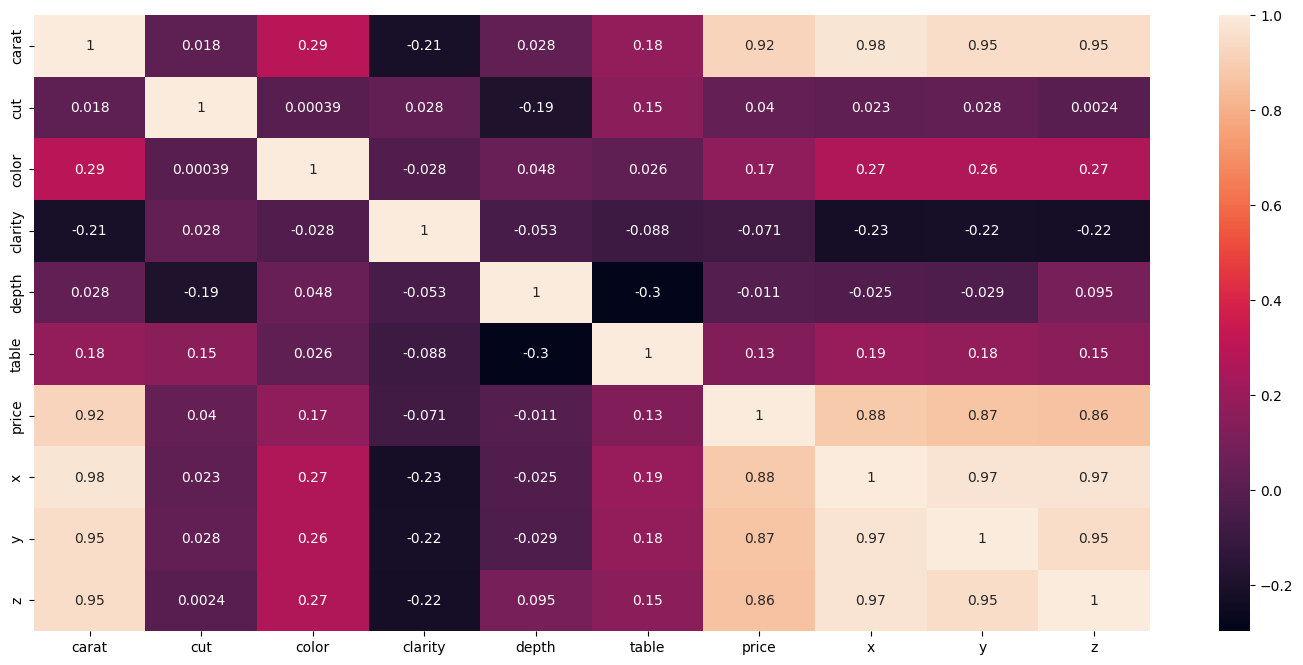

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 8))
sns.heatmap(df.corr(), annot=True, )
plt.show()

### Splitting data to training and tasting

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price", "depth", "clarity", "cut"])
y= df.price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scalling X data (feture columns) with Standard Scaler

In [12]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

### Modeling<br>
I choose RandomForestRegression because that model is enough for our datasets and minim to bias<br>

I Also use GridSearchCV technique tu search best params in out models

__Implemets parameters__

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(max_depth=None, min_samples_split=2, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Evaluate model with:
+ MSE
+ MAE
+ RMSE
+ R2 Score

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

mse_score = mean_squared_error(y_test, y_pred)
mae_score = mean_absolute_error(y_test, y_pred)
rmse_score = root_mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

print(f"MSE Score: {mse_score}")
print(f"MAE Score: {mae_score}")
print(f"RMSE Score: {rmse_score}")
print(f"R2 Score: {r2_score}")

MSE Score: 1311528.0639105537
MAE Score: 632.9420776074985
RMSE Score: 1145.2196574939471
R2 Score: 0.9139534167540241


### Try to predict

Take a sample

In [15]:
X_train.tail()

,carat,color,table,x,y,z
11311,1.00,4,58.0,6.51,6.46,3.92
44869,0.63,3,54.0,5.52,5.56,3.42
38271,0.32,6,54.9,4.39,4.42,2.72
860,0.90,6,59.0,6.13,6.03,3.82
15832,1.01,3,58.0,6.36,6.31,3.97


In [19]:
X_train.loc[38271].to_list()

[0.32, 6.0, 54.9, 4.39, 4.42, 2.72]

In [16]:
y_train[38271]

384

__predict__

In [17]:
model.predict([X_train.loc[38271].to_list()])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([419.36])

### Export model to pickle

In [18]:
import pickle
import os

path = "/content/drive/MyDrive/learn_ML_LKS/exercise/models/forecast_model.pkl"

os.makedirs(os.path.dirname(path), exist_ok=True)

with open(path, "wb") as pickle_file:
  pickle.dump(model, pickle_file)